In [12]:
import tempfile
import os
import numpy as np
from ase.calculators.vasp import VaspChargeDensity
from scipy.spatial import KDTree
import matplotlib.pyplot as plt

INORGANICS = ['Ag', 'S']

PATH = "/Users/adrianaladera/Desktop/MIT/research/VASP_calculations/3-positions/3methoxy/parchg/CHGCAR"

['Ag', 'Ag', 'Ag', 'Ag', 'S', 'S', 'S', 'S', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'O', 'O', 'O', 'O']
(56, 140, 180, 3)
(1411200, 3) (1411200,)
1411200 1000
1000 1000 1000


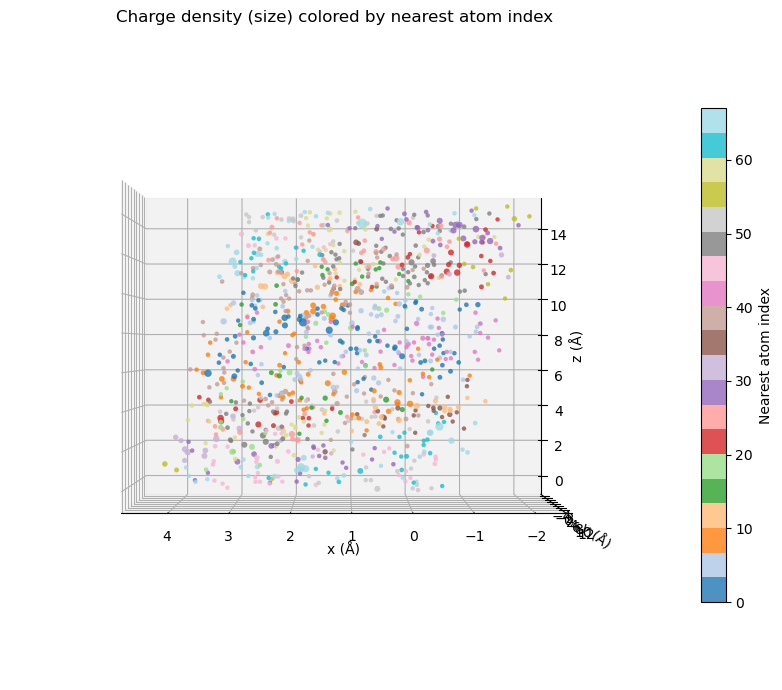

In [24]:
# https://github.com/AIforGreatGood/charge3net/blob/18290c63c0307792ab6da5ff98ee535cdb7376d6/src/utils/data.py#L125
def read_vasp(filecontent, read_spin=False):
    # Write to tmp file and read using ASE
    tmpfd, tmppath = tempfile.mkstemp(prefix="tmpcharge3net")
    tmpfile = os.fdopen(tmpfd, "wb")
    tmpfile.write(filecontent)
    tmpfile.close()
    vasp_charge = VaspChargeDensity(filename=tmppath)
    os.remove(tmppath)
    try:
        density = vasp_charge.chg[-1]  # separate density
        if read_spin:
            if len(vasp_charge.chgdiff) != 0:
                spin_density = vasp_charge.chgdiff[-1]
            else:
                # assume non-spin-polarized if there's no spin density data
                spin_density = np.zeros_like(density)
            density = np.stack([density, spin_density], axis=-1)
    except IndexError as e:
        print(e, f"\nFileconents of {filecontent} do not contain chg field")
    atoms = vasp_charge.atoms[-1]  # separate atom positions

    return density, atoms, np.zeros(3)  # TODO: Can we always assume origin at 0,0,0?


# https://github.com/AIforGreatGood/charge3net/blob/18290c63c0307792ab6da5ff98ee535cdb7376d6/src/utils/data.py#L77C1
def calculate_grid_pos(density, origin, cell):
    # Calculate grid positions
    ngridpts = np.array(density.shape)  # grid matrix
    grid_pos = np.meshgrid(
        np.arange(ngridpts[0]) / density.shape[0],
        np.arange(ngridpts[1]) / density.shape[1],
        np.arange(ngridpts[2]) / density.shape[2],
        indexing="ij",
    )
    grid_pos = np.stack(grid_pos, 3)
    grid_pos = np.dot(grid_pos, cell)
    grid_pos = grid_pos + origin
    return grid_pos

# https://github.com/AIforGreatGood/charge3net/blob/18290c63c0307792ab6da5ff98ee535cdb7376d6/src/utils/data.py#L224
def supercell_atoms_positions(atoms):
    atoms_positions = atoms.positions
    atomic_numbers = atoms.get_atomic_numbers()

    # repeat directions
    repeats = [-1, 0, 1]  # only need one repeat around unit cell to test for closest atom
    repeat_offsets = np.array([(x, y, z) for x in repeats for y in repeats for z in repeats])
    # total repeats in all dimensions
    total_repeats = repeat_offsets.shape[0]
    # project repeat cell offsets into cartesian space
    repeat_offsets = np.dot(repeat_offsets, atoms.get_cell())
    # tile grid positions, subtract offsets 
    # (subtracting grid positions is like adding atom positions)
    offset_grid_pos = np.repeat(atoms_positions[..., None, :], total_repeats, axis=-2)
    atomic_numbers = np.repeat(atomic_numbers[...,None], total_repeats, axis=-2)
    offset_grid_pos -= repeat_offsets

    atoms_positions = offset_grid_pos.reshape(np.prod(offset_grid_pos.shape[:2]),3)
    return atoms_positions, atomic_numbers


def main():
    with open(PATH, "rb") as f:
        filecontent = f.read()
    density, atoms, origin = read_vasp(filecontent)
    atom_pos = [atoms.get_positions()[i] for i in range(len(atoms.get_positions())) if atoms.get_chemical_symbols()[i] in INORGANICS]
    grid_pos = calculate_grid_pos(density, origin, atoms.cell)
    print(atoms.get_chemical_symbols())

    print(grid_pos.shape)

    density = density.reshape(-1)
    grid_pos = grid_pos.reshape(-1, 3)

    print(grid_pos.shape, density.shape)

    kdtree = KDTree(atoms.positions)
    # kdtree = KDTree(atom_pos)
    # kd tree is a data structure that allows for fast nearest neighbor search

    atom_min_dist, atom_min_idx = kdtree.query(grid_pos, k=1)
    # atom_min_idx is the index of the closest atom to the grid point
    # atom_min_dist is the distance to the closest atom

    # Plot density at grid positions, colored by nearest atom index
    n = grid_pos.shape[0]
    sample_size = min(1000, n)  # reduce for speed/visibility
    rng = np.random.default_rng(0)
    if n > sample_size:
        idx = rng.choice(n, size=sample_size, replace=False)
    else:
        idx = np.arange(n)

    print(n, sample_size)

    pos = grid_pos[idx]
    dens = density[idx]
    colors = atom_min_idx[idx]

    print(len(pos), len(dens), len(colors))

    # encode density in marker size
    dmin, dmax = dens.min(), dens.max()
    sizes = 10.0 + 40.0 * ((dens - dmin) / (dmax - dmin + 1e-12))

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")
    sc = ax.scatter(
        pos[:, 0], pos[:, 1], pos[:, 2],
        c=colors, cmap="tab20",
        s=sizes, alpha=0.8, linewidths=0
    )
    cbar = fig.colorbar(sc, ax=ax, fraction=0.03, pad=0.05)
    cbar.set_label("Nearest atom index")
    ax.view_init(elev=0, azim=90)
    ax.set_xlabel("x (Å)")
    ax.set_ylabel("y (Å)")
    ax.set_zlabel("z (Å)")
    ax.set_title("Charge density (size) colored by nearest atom index")
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()
